In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
import joblib

RANDOM_SEED = 9876

PROJECT_ROOT = Path('.')
DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'

for d in [PROCESSED_DIR, MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)


In [2]:
central_path = DATA_DIR / 'Central2024P.csv'
test_path = DATA_DIR / 'Central2024testP.csv'


central = pd.read_csv(central_path)
central_test_external = pd.read_csv(test_path)

central.head()


,Price,Area,Age,Tenure,Purchaser,Region
0,1412345.0,678.13,7,Leasehold,HDB,Bishan
1,960000.0,484.38,7,Leasehold,Private,Bishan
2,2180000.0,1280.92,8,Leasehold,HDB,Bishan
3,2450000.0,1248.62,12,Leasehold,Private,Bishan
4,2300000.0,1367.03,8,Leasehold,Private,Bishan


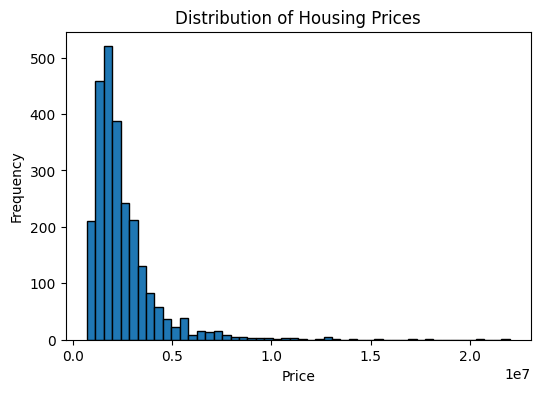

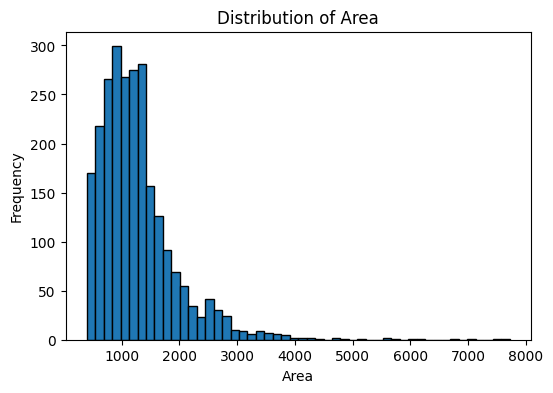

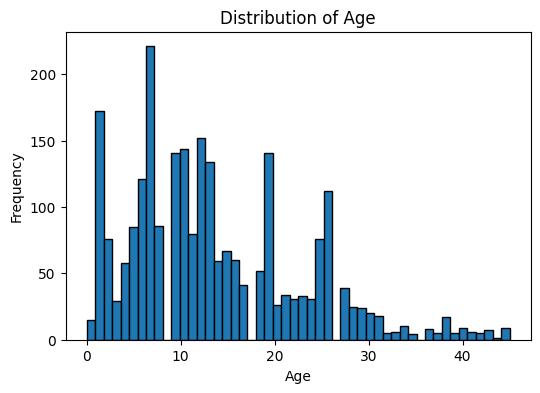

In [3]:
plt.figure(figsize=(6, 4))
plt.hist(central['Price'], bins=50, edgecolor='black')
plt.title('Distribution of Housing Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.savefig(FIGURES_DIR / 'price_hist.png', dpi=200)
plt.show()


plt.figure(figsize=(6,4))
plt.hist(central['Area'], bins=50, edgecolor='black')
plt.title('Distribution of Area')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.savefig(FIGURES_DIR / 'area_hist.png', dpi=200)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(central['Age'], bins=50, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig(FIGURES_DIR / 'age_hist.png', dpi=200)
plt.show()


# here we see that price and area are right skewed, will log transform both 

## Train/Validation/Test Splits and Preprocessing

- 10% holdout for final evaluation 
- 80/20 train/validation split for model comparison within training set


In [4]:
central['Price'] = np.log1p(central['Price'])
central['Area'] = np.log1p(central['Area'])


central_train, central_test = train_test_split(
    central,
    test_size=0.15,
    random_state=RANDOM_SEED
)



central_train.shape, central_test.shape

((2125, 6), (375, 6))

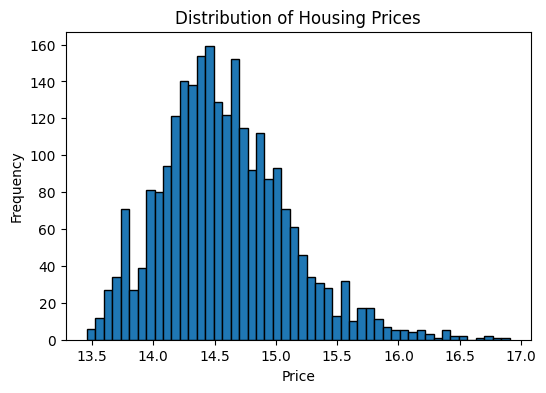

In [5]:
X_train = central_train.drop(columns=['Price'])  
y_train = central_train['Price']
X_test = central_test.drop(columns=['Price'])
y_test = central_test['Price']

plt.figure(figsize=(6, 4))
plt.hist(central['Price'], bins=50, edgecolor='black')
plt.title('Distribution of Housing Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

## Polynomial degree selection (Area, Age) via 10-fold CV



5 8


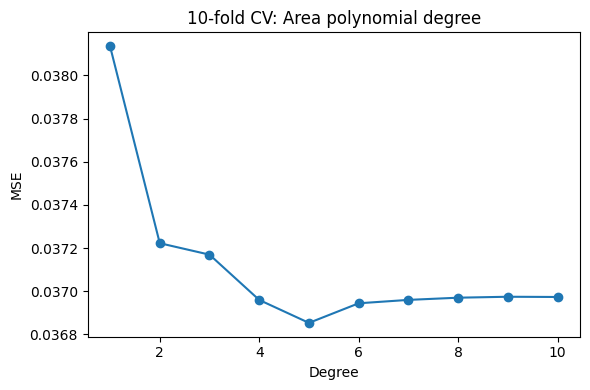

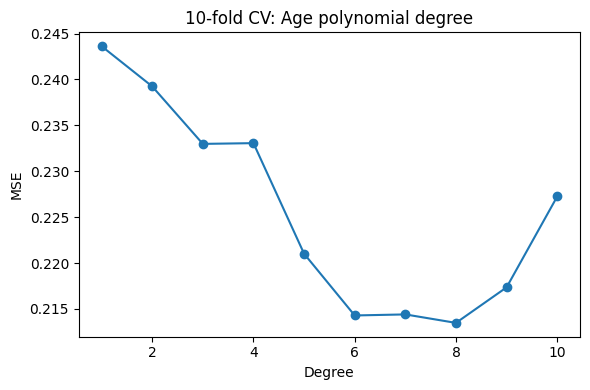

In [6]:
def poly_cv_mse(df, feature, target='Price', max_degree=10, k=10, random_state=RANDOM_SEED):
    kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
    mse_per_degree = []
    X = df[[feature]].values
    y = df[target].values

    for degree in range(1, max_degree + 1):
        fold_mse = []
        for train_idx, test_idx in kf.split(X):
            X_train = X[train_idx]
            X_test = X[test_idx]
            y_train = y[train_idx]
            y_test = y[test_idx]

            # Create polynomial features manually
            X_train_poly = np.column_stack([X_train ** d for d in range(1, degree + 1)])
            X_test_poly = np.column_stack([X_test ** d for d in range(1, degree + 1)])

            model = LinearRegression()
            model.fit(X_train_poly, y_train)
            preds = model.predict(X_test_poly)
            fold_mse.append(mean_squared_error(y_test, preds))

        mse_per_degree.append(np.mean(fold_mse))

    return mse_per_degree

area_cv_mse = poly_cv_mse(central_train, 'Area')
age_cv_mse = poly_cv_mse(central_train, 'Age')

best_degree_area = int(np.argmin(area_cv_mse) + 1)
best_degree_age = int(np.argmin(age_cv_mse) + 1)

print(best_degree_area, best_degree_age)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), area_cv_mse, marker='o')
plt.title('10-fold CV: Area polynomial degree')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_poly_area.png', dpi=200)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), age_cv_mse, marker='o')
plt.title('10-fold CV: Age polynomial degree')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_poly_age.png', dpi=200)
plt.show()

## Feature Engineering Pipeline

Includes:
- Groups region categories of low frequency into one category
- Polynomial terms for Area/Age (CV-selected)
- Interactions: Area×Age



In [7]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, degree_area=1, degree_age=1):    
        self.degree_area = degree_area
        self.degree_age = degree_age

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
    
        # Polynomial terms
        for d in range(2, self.degree_area + 1):
            df[f'Area_^_{d}'] = df['Area'] ** d
        for d in range(2, self.degree_age + 1):
            df[f'Age_^_{d}'] = df['Age'] ** d

        # Interactions
        df['Area_x_Age'] = df['Area'] * df['Age']

        region_dummies = pd.get_dummies(df['Region'], prefix='Region')
        for col in region_dummies.columns:
            df[f'Area_x_{col}'] = df['Area'] * region_dummies[col]

        tenure_dummies = pd.get_dummies(df['Tenure'], prefix='Tenure')
        for col in tenure_dummies.columns:
            df[f'Area_x_{col}'] = df['Area'] * tenure_dummies[col]

        

        return df   

feature_engineer = FeatureEngineer(degree_area=best_degree_area, degree_age= best_degree_age)
sample_fe = feature_engineer.fit_transform(X_train)
numeric_features = sample_fe.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [col for col in X_train.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
                    ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)


## Model Training (Lasso, Ridge, ElasticNet, XGBoost)

In [8]:
lasso = Pipeline([
    ('feature_engineer', feature_engineer),
    ('preprocess', preprocessor),
    ('model', LassoCV(cv=5, random_state=RANDOM_SEED))
])

ridge = Pipeline([
    ('feature_engineer', feature_engineer),
    ('preprocess', preprocessor),
    ('model', RidgeCV(alphas=np.logspace(-3, 3, 50)))
])

elastic = Pipeline([
    ('feature_engineer', feature_engineer),
    ('preprocess', preprocessor),
    ('model', ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=5, random_state=RANDOM_SEED))
])

xgb = Pipeline([
    ('feature_engineer', feature_engineer),
    ('preprocess', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=RANDOM_SEED
    ))
])

models = {
    'LassoCV': lasso,
    'RidgeCV': ridge,
    'ElasticNetCV': elastic
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [9]:
# Stepwise XGBoost hyperparameter tuning (GridSearchCV per group)
# sequential group tuning (max_depth/min_child_weight) ->
# (subsample/colsample_bytree) -> (learning_rate/n_estimators)

stepwise_cv_results = {}
stepwise_best_params = {}

base_fixed_params = {
    "model__learning_rate": 0.1,
    "model__n_estimators": 1000,
}

xgb_working = xgb.set_params(**base_fixed_params)

# GROUP 1: max_depth, min_child_weight
group_1_grid = {
    "model__max_depth": [3, 4, 5, 6],
    "model__min_child_weight": [1, 3, 5,7, 10],
}

group_1_search = GridSearchCV(
    estimator=xgb_working,
    param_grid=group_1_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    refit=True,
)
group_1_search.fit(X_train, y_train)

stepwise_cv_results["group_1"] = pd.DataFrame(group_1_search.cv_results_)
stepwise_best_params.update(group_1_search.best_params_)

xgb_working = group_1_search.best_estimator_

# GROUP 2: subsample, colsample_bytree
# (GROUP 1 fixed at best; GROUP 3 fixed at initial values)
xgb_working = xgb_working.set_params(
    model__learning_rate=0.1,
    model__n_estimators=1000,
)

group_2_grid = {
    "model__subsample": [0.5, 0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.5, 0.7, 0.8, 1.0],
}

group_2_search = GridSearchCV(
    estimator=xgb_working,
    param_grid=group_2_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    refit=True,
)
group_2_search.fit(X_train, y_train)

stepwise_cv_results["group_2"] = pd.DataFrame(group_2_search.cv_results_)
stepwise_best_params.update(group_2_search.best_params_)

xgb_working = group_2_search.best_estimator_

# GROUP 3: learning_rate, n_estimators 
# (GROUP 1-2 fixed at best)

group_3_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__n_estimators": [400, 600, 1000, 1500]
    ,
}

group_3_search = GridSearchCV(
    estimator=xgb_working,
    param_grid=group_3_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    refit=True,
)
group_3_search.fit(X_train, y_train)

stepwise_cv_results["group_3"] = pd.DataFrame(group_3_search.cv_results_)
stepwise_best_params.update(group_3_search.best_params_)

best_xgb = group_3_search.best_estimator_

stepwise_best_params

## Validation performance comparison (primary metric: RMSE)

In [10]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_model(name, model, X, y_log):
    preds_log = model.predict(X)
    preds = np.expm1(preds_log)
    y_true = np.expm1(y_log)
    return {
        'Model': name,
        'RMSE': rmse(y_true, preds),
        'MAE': mean_absolute_error(y_true, preds),
        'R2': r2_score(y_true, preds),
        'MAPE': mape(y_true, preds)
    }

results = []
for name, model in models.items():
    results.append(evaluate_model(name, model, X_test, y_test))

results.append(evaluate_model('XGBoost', best_xgb, X_test, y_test))

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df.to_markdown(index=False)

,Model,RMSE,MAE,R2,MAPE
3,XGBoost,380954.704542,194292.283333,0.935730,7.000256
1,RidgeCV,555101.837853,299727.398574,0.863540,10.167426
0,LassoCV,560069.884193,307249.382222,0.861087,10.530691
2,ElasticNetCV,560321.771742,307348.189418,0.860962,10.532968


## Fit best model on full data set

In [11]:
best_model_name = results_df.iloc[0]['Model']
best_model = {
    'LassoCV': models['LassoCV'],
    'RidgeCV': models['RidgeCV'],
    'ElasticNetCV': models['ElasticNetCV'],
    'XGBoost': best_xgb
}[best_model_name]



full_train = central.drop(columns=['Price'])

best_model.fit(full_train, central['Price'])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineer', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,degree_area,5
,degree_age,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If 

## External test data (Central2024testP.csv)

In [12]:
X_external = central_test_external.drop(columns=['Price'])
X_external['Area'] = np.log1p(X_external['Area'])
y_external = np.log1p(central_test_external['Price'])
external_metrics = evaluate_model(best_model_name, best_model, X_external, y_external)
external_metrics 

{'Model': 'XGBoost',
 'RMSE': np.float64(694534.1955838784),
 'MAE': 270920.21928746917,
 'R2': 0.9189981877798616,
 'MAPE': np.float64(7.551146731635691)}

## Diagnostics and plots

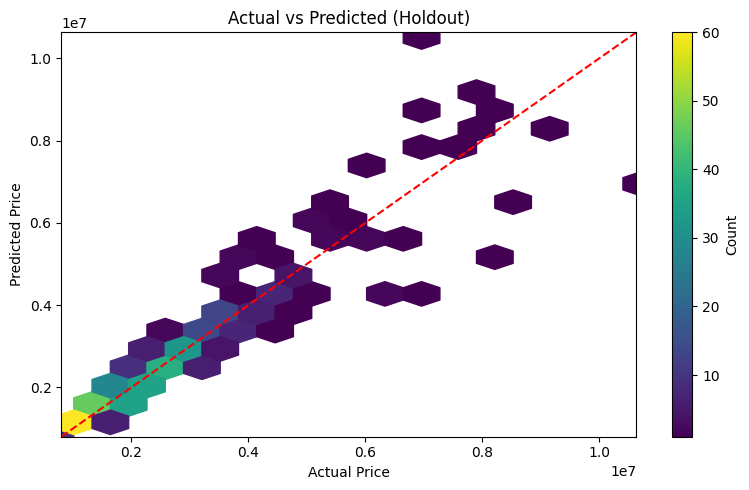

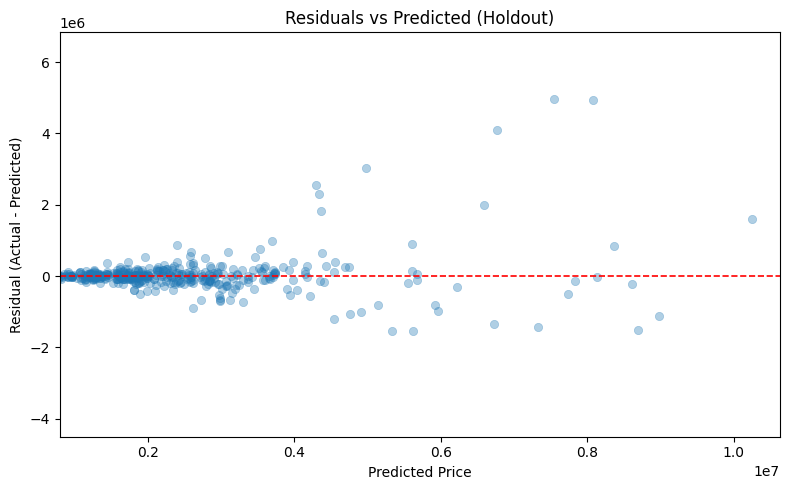

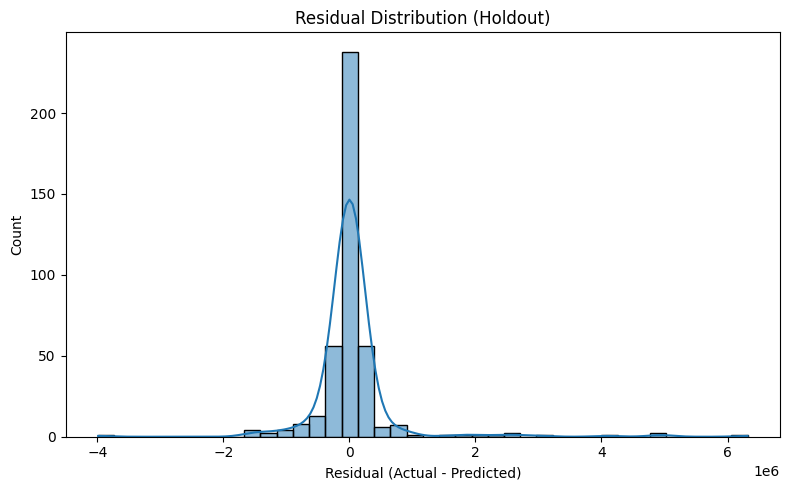

,y_true,y_pred,residual,abs_error,abs_pct_error
0,3000000.0,3247167.000,-247167.000,247167.000,8.238900
1,1910000.0,1916641.375,-6641.375,6641.375,0.347716
2,1380000.0,1378163.250,1836.750,1836.750,0.133098
3,1025000.0,1139318.750,-114318.750,114318.750,11.153049
4,1170000.0,1134291.625,35708.375,35708.375,3.051998


In [13]:
def plot_pred_vs_actual(
    *,
    y_true_log,
    y_pred_log,
    figures_dir,
    prefix,
    title_suffix="", ):
    y_true = np.expm1(np.asarray(y_true_log).reshape(-1))
    y_pred = np.expm1(np.asarray(y_pred_log).reshape(-1))

    pred_df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    pred_df["residual"] = pred_df["y_true"] - pred_df["y_pred"]
    pred_df["abs_error"] = pred_df["residual"].abs()
    pred_df["abs_pct_error"] = (
        (pred_df["abs_error"] / pred_df["y_true"]) * 100.0
    )

    lo = float(np.nanpercentile(pred_df[["y_true", "y_pred"]].to_numpy(), 1))
    hi = float(np.nanpercentile(pred_df[["y_true", "y_pred"]].to_numpy(), 99))

    # Actual vs Predicted (hexbin)
    plt.figure(figsize=(8, 5))
    plt.hexbin(
        pred_df["y_true"],
        pred_df["y_pred"],
        gridsize=50,
        cmap="viridis",
        mincnt=1,
    )
    plt.plot([lo, hi], [lo, hi], "r--", linewidth=1.5)
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.colorbar(label="Count")
    plt.title(f"Actual vs Predicted{title_suffix}")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.tight_layout()
    plt.savefig(figures_dir / f"{prefix}_actual_vs_pred.png", dpi=220)
    plt.show()

    # Residuals vs Predicted
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=pred_df,
        x="y_pred",
        y="residual",
        alpha=0.35,
        edgecolor=None,
    )
    plt.axhline(0.0, color="red", linestyle="--", linewidth=1.2)
    plt.xlim(lo, hi)
    plt.title(f"Residuals vs Predicted{title_suffix}")
    plt.xlabel("Predicted Price")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.tight_layout()
    plt.savefig(figures_dir / f"{prefix}_residuals_vs_pred.png", dpi=200)
    plt.show()

    # Residual distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(pred_df["residual"], bins=40, kde=True)
    plt.title(f"Residual Distribution{title_suffix}")
    plt.xlabel("Residual (Actual - Predicted)")
    plt.tight_layout()
    plt.savefig(figures_dir / f"{prefix}_residual_hist.png", dpi=200)
    plt.show()

    return pred_df


pred_holdout_log = best_model.predict(X_external)

pred_df_holdout = plot_pred_vs_actual(
    y_true_log=y_external,
    y_pred_log=pred_holdout_log,
    figures_dir=FIGURES_DIR,
    prefix="holdout",
    title_suffix=" (Holdout)",
)

pred_df_holdout.head()

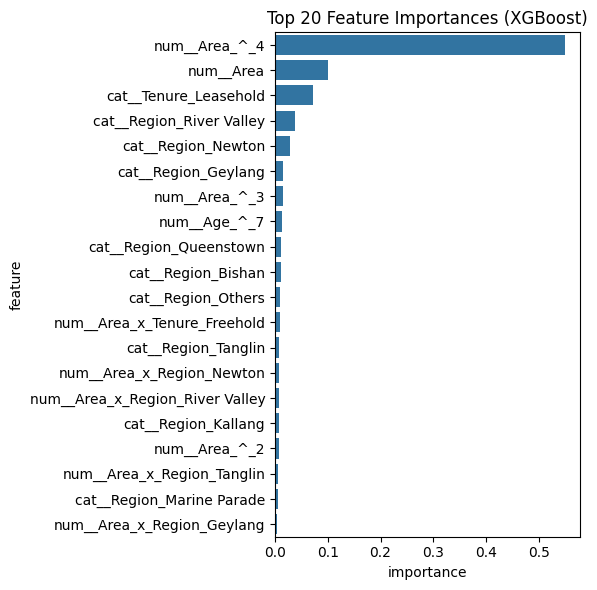

In [14]:
# XGBoost feature importance
if best_model_name == 'XGBoost':
    booster = best_model.named_steps['model']
    importance = booster.feature_importances_
    feature_names = (
        best_model.named_steps['preprocess']
        .get_feature_names_out()
    )
    fi = pd.DataFrame({'feature': feature_names, 'importance': importance})
    fi = fi.sort_values('importance', ascending=False).head(20)

    plt.figure(figsize=(6, 6))
    sns.barplot(data=fi, x='importance', y='feature')
    plt.title('Top 20 Feature Importances (XGBoost)')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'xgb_feature_importance.png', dpi=200)
    plt.show()

## Save artefacts

In [15]:
central_train.to_csv(PROCESSED_DIR / 'central_train.csv', index=False)
central_test.to_csv(PROCESSED_DIR / 'central_test.csv', index=False)

joblib.dump(best_model, MODELS_DIR / f'best_model_{best_model_name}.joblib')

results_df.to_csv(PROCESSED_DIR / 'model_comparison.csv', index=False)
pd.DataFrame([external_metrics]).to_csv(PROCESSED_DIR / 'external_metrics.csv', index=False)

results_df

,Model,RMSE,MAE,R2,MAPE
3,XGBoost,380954.704542,194292.283333,0.935730,7.000256
1,RidgeCV,555101.837853,299727.398574,0.863540,10.167426
0,LassoCV,560069.884193,307249.382222,0.861087,10.530691
2,ElasticNetCV,560321.771742,307348.189418,0.860962,10.532968
